In [4]:
import sys
import os

# Add project root to Python path
PROJECT_ROOT = os.path.abspath(os.path.join(".."))
sys.path.append(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
from src.data_ingestion.load_data import load_raw_data

sales_path = "../data/raw/McKesson_Large_Demand_Forecasting_Dataset.csv"
season_path = "../data/raw/daily_dataset_2023.csv"

sales_df, season_df = load_raw_data(sales_path, season_path)

sales_df.head()


,date,product_id,product_name,category,region,units_sold,unit_price,market_trend_index,is_holiday,flu_alert_level,economic_index
0,2023-01-01,DRUG001,Atorvastatin 20mg,Pharmaceuticals,North America,1149,1.25,1.12,0,Low,96.56
1,2023-01-01,DRUG001,Atorvastatin 20mg,Pharmaceuticals,Europe,958,1.25,0.92,0,Medium,102.08
2,2023-01-01,DRUG002,Amoxicillin 500mg,Pharmaceuticals,North America,859,0.85,0.95,0,Low,100.25
3,2023-01-01,DRUG002,Amoxicillin 500mg,Pharmaceuticals,Europe,1162,0.85,1.03,0,Medium,96.39
4,2023-01-01,DRUG003,Insulin Glargine 10ml,Pharmaceuticals,North America,727,25.00,1.04,0,Low,100.14


In [6]:
from src.feature_engineering.build_features import build_features

df, scaler, encoders = build_features(sales_df, season_df)

df.head()


,date,product_name,category,units_sold,unit_price,market_trend_index,is_holiday,flu_alert_level,economic_index,month_day,season,day_of_week,week_of_month,month,is_weekend
0,2023-01-01,1,1,0.527791,0.016563,0.733333,0,1,0.156,01-01,3,1.0,0.0,0.0,1.0
1,2023-01-01,1,1,0.440055,0.016563,0.066667,0,2,0.708,01-01,3,1.0,0.0,0.0,1.0
2,2023-01-01,0,1,0.394580,0.000000,0.166667,0,1,0.525,01-01,3,1.0,0.0,0.0,1.0
3,2023-01-01,0,1,0.533762,0.000000,0.433333,0,2,0.139,01-01,3,1.0,0.0,0.0,1.0
4,2023-01-01,2,1,0.333946,1.000000,0.466667,0,1,0.514,01-01,3,1.0,0.0,0.0,1.0


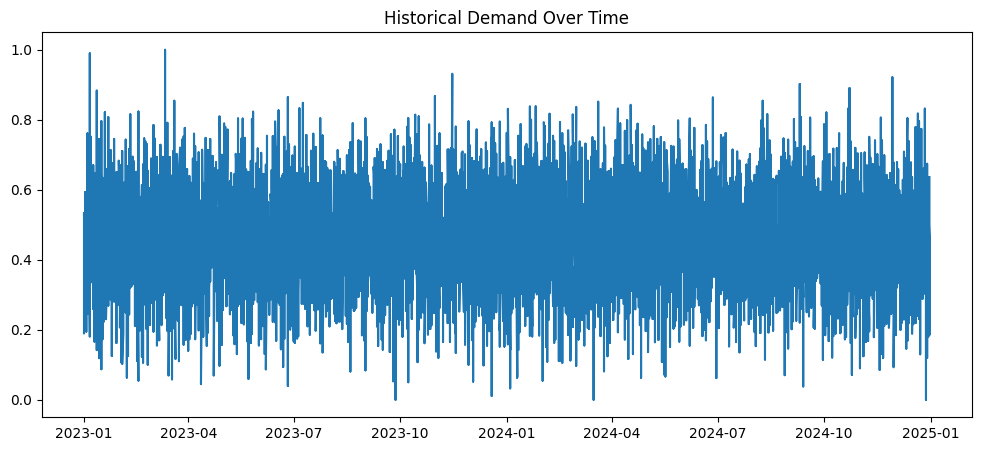

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['units_sold'])
plt.title("Historical Demand Over Time")
plt.show()


In [8]:
df['season'].value_counts().sort_index()

season
0    1220
1    2440
2    1840
3    1800
4      10
Name: count, dtype: int64

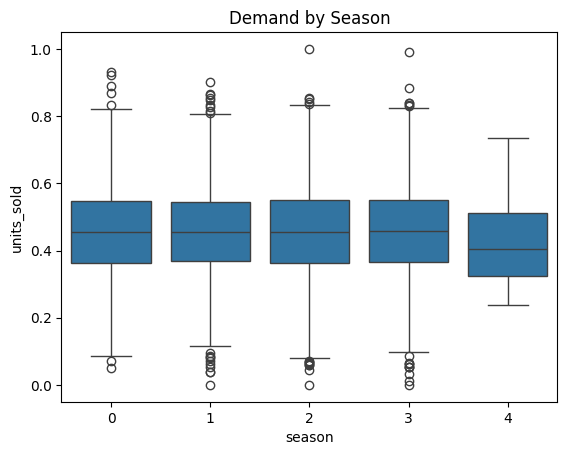

In [9]:
sns.boxplot(x='season', y='units_sold', data=df)
plt.title("Demand by Season")
plt.show()


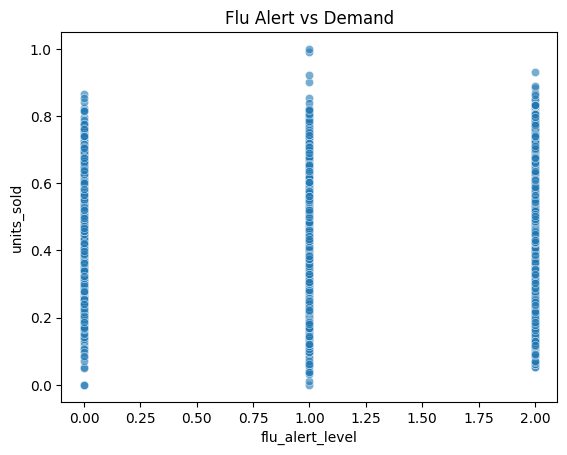

In [10]:
sns.scatterplot(
    data=df,
    x='flu_alert_level',
    y='units_sold',
    alpha=0.6
)
plt.title("Flu Alert vs Demand")
plt.show()


In [11]:
from src.sequences.create_sequences import create_lstm_sequences

feature_cols = [
    'product_name', 'category', 'unit_price',
    'market_trend_index', 'is_holiday',
    'flu_alert_level', 'economic_index',
    'season', 'day_of_week', 'week_of_month',
    'month', 'is_weekend'
]

X, y = create_lstm_sequences(
    df=df,
    feature_cols=feature_cols,
    target_col="units_sold",
    lookback=30
)

X.shape, y.shape


((7280, 30, 12), (7280,))

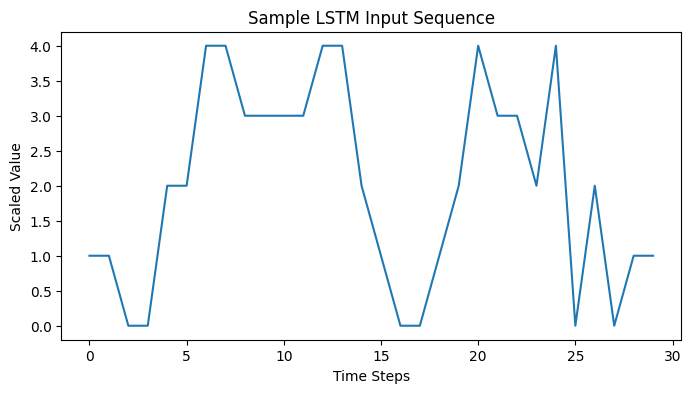

In [12]:
plt.figure(figsize=(8,4))
plt.plot(X[0, :, 0])
plt.title("Sample LSTM Input Sequence")
plt.xlabel("Time Steps")
plt.ylabel("Scaled Value")
plt.show()


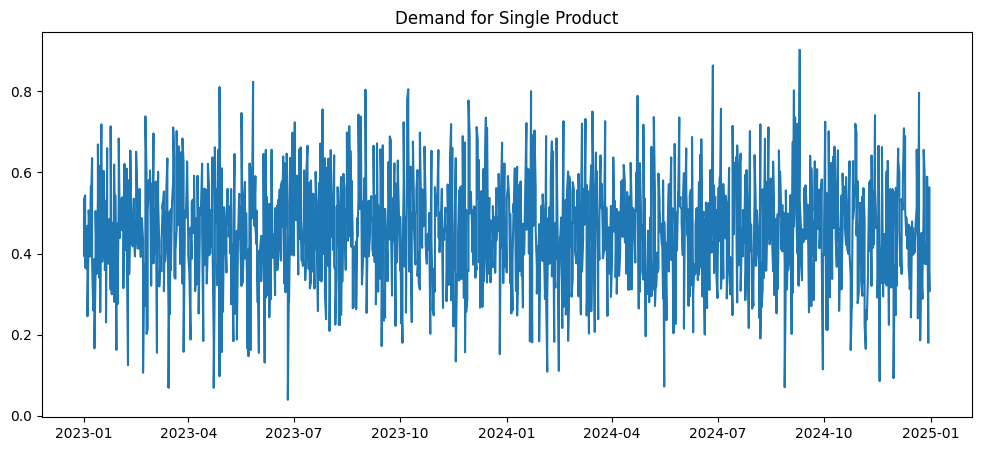

In [13]:
sku_df = df[df['product_name'] == 0]

plt.figure(figsize=(12,5))
plt.plot(sku_df['date'], sku_df['units_sold'])
plt.title("Demand for Single Product")
plt.show()
